model parameters
slope (Coefficient): -9.33
intercept: 85.68



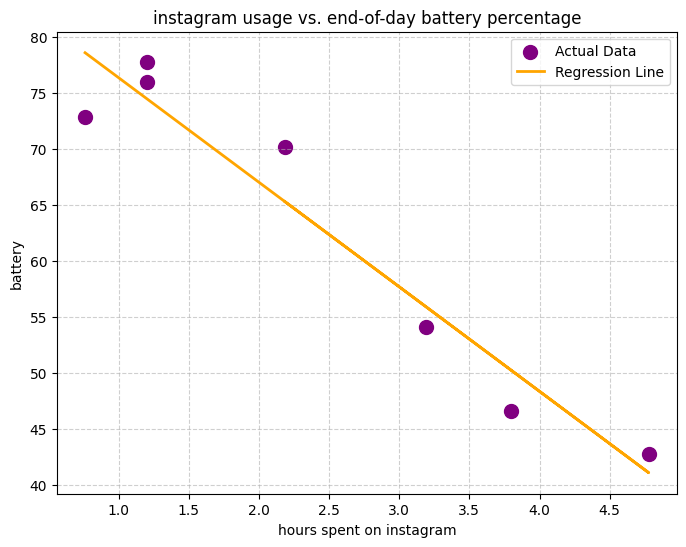

12.820638337434309


In [1]:
#session 5 1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)
instagram_hours = np.random.uniform(0.5, 5.0, size=(7, 1))

noise = np.random.normal(0, 5, size=(7, 1))
battery_percentage = 95 - 12 * instagram_hours + noise
battery_percentage = np.clip(battery_percentage, 0, 100) # Keep battery within 0-100%

plt.figure(figsize=(8, 6))
plt.scatter(instagram_hours, battery_percentage, color='purple', label='Actual Data', s=100)

#2
model = LinearRegression()
model.fit(instagram_hours, battery_percentage)

slope = model.coef_[0][0]
intercept = model.intercept_[0]

print("model parameters")
print(f"slope (Coefficient): {slope:.2f}")
print(f"intercept: {intercept:.2f}\n")

#3
predicted_battery = model.predict(instagram_hours)
plt.plot(instagram_hours, predicted_battery, color='orange', linewidth=2, label='Regression Line')
plt.title('instagram usage vs. end-of-day battery percentage')
plt.xlabel('hours spent on instagram')
plt.ylabel('battery')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#4
mse = mean_squared_error(battery_percentage, predicted_battery)
print(mse)

In [10]:
#session 6 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = pd.read_csv("/content/Book1.csv")

x = data[['RAM_GB', 'Storage_GB', 'Camera_MP']]
y = data['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(y_pred)

#2
print(model.intercept_)
coefficients = pd.DataFrame({
    "x": x.columns,
    "Coefficient": model.coef_
})
print(coefficients)

#4
importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": abs(model.coef_)
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)
print(importance)




[63949.55075838 19939.89502348]
151.45296446846623
            x  Coefficient
0      RAM_GB  2007.564098
1  Storage_GB    27.453152
2   Camera_MP    88.105292
      Feature  Coefficient
0      RAM_GB  2007.564098
2   Camera_MP    88.105292
1  Storage_GB    27.453152


In [12]:
#session 6 5
X_new = data[['RAM_GB', 'Camera_MP']]

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()

model2.fit(X_train, y_train)

print("New Intercept")

print(model2.intercept_)

print()

print("New Coefficients")

print(pd.DataFrame({
    "Feature": X_new.columns,
    "Coefficient": model2.coef_}))

New Intercept
245.84292657968035

New Coefficients
     Feature  Coefficient
0     RAM_GB  2025.262215
1  Camera_MP   154.978895


In [13]:
#session 7 1
import numpy as np
from sklearn.metrics import mean_squared_error


actual = np.array([25, 30, 18, 40, 35, 22, 28, 32, 26, 38])
predicted = np.array([27, 29, 20, 38, 36, 24, 30, 31, 25, 40])

mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)

print(mse)
print(rmse)

2.8
1.6733200530681511


In [14]:
#session 7 2
from sklearn.metrics import mean_absolute_error, r2_score

actual_prices = [15000, 18000, 25000, 30000, 22000, 27000, 35000]
predicted_prices = [15500, 17500, 24500, 31000, 22500, 26500, 34500]

def evaluate(actual, predicted):

    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    print(mae)
    print(r2)
evaluate(actual_prices, predicted_prices)

571.4285714285714
0.99125


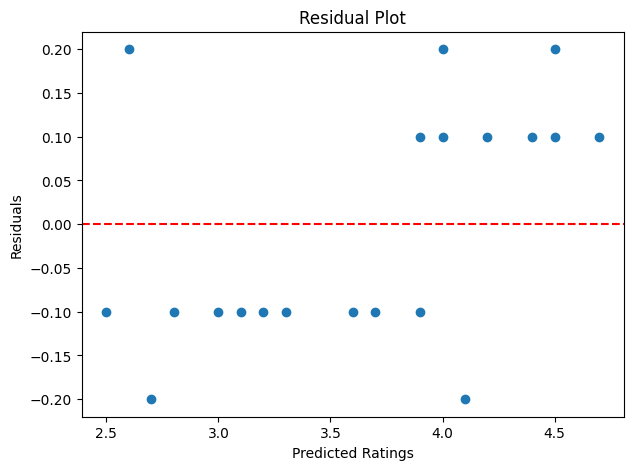

In [15]:
#session 7 3
import matplotlib.pyplot as plt
import numpy as np

actual = np.array([
    4.5,4.0,3.8,2.5,4.7,
    3.2,2.8,4.1,3.9,2.9,
    4.8,3.5,2.7,4.3,3.0,
    4.6,2.4,3.6,4.2,3.1
])

predicted = np.array([
    4.4,3.9,3.9,2.7,4.5,
    3.3,2.6,4.0,4.1,3.0,
    4.7,3.6,2.8,4.2,3.1,
    4.5,2.5,3.7,4.0,3.2
])


residuals = actual - predicted

plt.figure(figsize=(7,5))
plt.scatter(predicted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Ratings")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [16]:
#session 8 1
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

data = pd.read_csv("/content/mobile .csv")

x = data[['RAM', 'Storage']]
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

print(x)
print(x_poly)
print(poly.get_feature_names_out())

   RAM  Storage
0    4       64
1    6      128
2    8      128
3    8      256
4   12      256
5    6       64
6    4       32
7   12      512
[[1.00000e+00 4.00000e+00 6.40000e+01 1.60000e+01 2.56000e+02 4.09600e+03]
 [1.00000e+00 6.00000e+00 1.28000e+02 3.60000e+01 7.68000e+02 1.63840e+04]
 [1.00000e+00 8.00000e+00 1.28000e+02 6.40000e+01 1.02400e+03 1.63840e+04]
 [1.00000e+00 8.00000e+00 2.56000e+02 6.40000e+01 2.04800e+03 6.55360e+04]
 [1.00000e+00 1.20000e+01 2.56000e+02 1.44000e+02 3.07200e+03 6.55360e+04]
 [1.00000e+00 6.00000e+00 6.40000e+01 3.60000e+01 3.84000e+02 4.09600e+03]
 [1.00000e+00 4.00000e+00 3.20000e+01 1.60000e+01 1.28000e+02 1.02400e+03]
 [1.00000e+00 1.20000e+01 5.12000e+02 1.44000e+02 6.14400e+03 2.62144e+05]]
['1' 'RAM' 'Storage' 'RAM^2' 'RAM Storage' 'Storage^2']


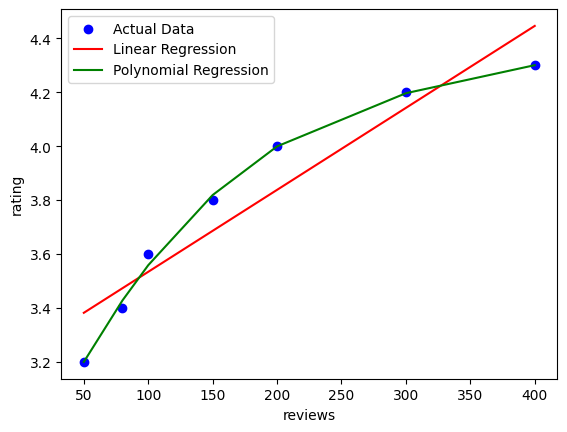

In [19]:
#session 8 2
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Load dataset
data = pd.read_csv("/content/zomato .csv")

x = data[['Reviews']]
y = data['Rating']

linear = LinearRegression()
linear.fit(x, y)

poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x)

poly_model = LinearRegression()
poly_model.fit(x_poly, y)

linear_pred = linear.predict(x)
poly_pred = poly_model.predict(x_poly)

plt.scatter(x, y, color="blue", label="Actual Data")
plt.plot(x, linear_pred, color="red", label="Linear Regression")
plt.plot(x, poly_pred, color="green", label="Polynomial Regression")
plt.xlabel("reviews")
plt.ylabel("rating")
plt.legend()
plt.show()

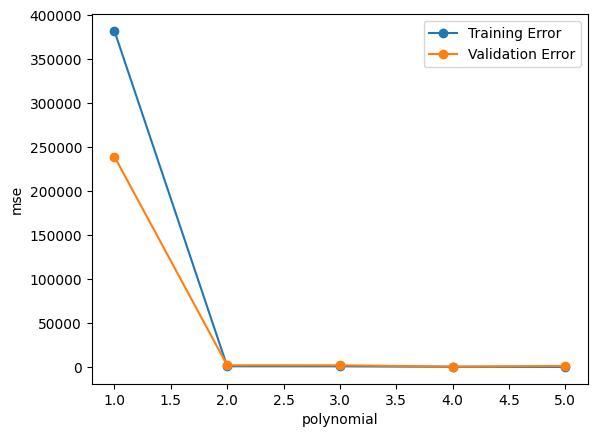

In [23]:
#session 8 3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

data = pd.read_csv("/content/instagram.csv")

x = data[['Posts']]
y = data['Followers']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

train_error = []
test_error = []

for degree in range(1,6):

    poly = PolynomialFeatures(degree=degree)

    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    model = LinearRegression()

    model.fit(x_train_poly, y_train)
    train_pred = model.predict(x_train_poly)
    test_pred = model.predict(x_test_poly)
    train_error.append(mean_squared_error(y_train, train_pred))
    test_error.append(mean_squared_error(y_test, test_pred))
plt.plot(range(1,6), train_error, marker='o', label="Training Error")
plt.plot(range(1,6), test_error, marker='o', label="Validation Error")
plt.xlabel("polynomial")
plt.ylabel("mse")
plt.legend()
plt.show()

In [25]:
#session 8 4
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = pd.read_csv("/content/mobile .csv")

x = data[['RAM','Storage']]
y = data['Price']

poly = PolynomialFeatures(degree=3)

x_poly = poly.fit_transform(x)

x_train,x_test,y_train,y_test = train_test_split(
    x_poly,y,test_size=0.3,random_state=42
)


lr = LinearRegression()

lr.fit(x_train,y_train)

pred1 = lr.predict(x_test)

ridge = Ridge(alpha=1.0)

ridge.fit(x_train,y_train)
pred2 = ridge.predict(x_test)

print(mean_squared_error(y_test,pred1))
print(mean_squared_error(y_test,pred2))

1839005.5089290093
1839005.6791109722


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.73041e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [26]:
#session 9 1
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv("/content/spotify.csv")

x = data[['Danceability','Energy','Loudness','Tempo']]
y = data['Popularity']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

print(x.head())
print(y.head())

   Danceability  Energy  Loudness  Tempo
0          0.65    0.72        -5    120
1          0.55    0.60        -8    110
2          0.80    0.85        -4    130
3          0.70    0.78        -6    125
4          0.45    0.50       -10    100
0    70
1    55
2    90
3    80
4    40
Name: Popularity, dtype: int64


In [28]:
#session 9 2
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
for feature, coef in zip(x.columns, lasso.coef_):
    print(feature, ":", coef)

print( lasso.intercept_)

Danceability : -4.252157893755006
Energy : -0.002890684964637279
103.55180641887837


In [30]:
#session 9 3
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

for feature, coef in zip(x.columns, ridge.coef_):
    print(feature, ":", coef)

print(ridge.intercept_)

Danceability : 0.07766811561619452
Energy : 0.2524881735135445
Loudness : 0.11114696187351235
Tempo : 1.479104843125662
-106.10066956800051


In [31]:
#session 9 4
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(x_train, y_train)

for feature, coef in zip(x.columns, elastic.coef_):
    print(feature, ":", coef)
print(elastic.intercept_)

Danceability : 0.0
Energy : 0.0
Loudness : 0.0
Tempo : 1.5028113131484584
-109.39880333538434


In [ ]:
#session 10 1
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print( sigmoid(-2))
print( sigmoid(0))
print( sigmoid(3))

In [33]:
#session 10 2
import pandas as pd
from sklearn.linear_model import LogisticRegression

data = pd.read_csv("/content/instagram.csv")

x = data[['Likes', 'Has_Caption']]
y = data['Viral']
model = LogisticRegression()

model.fit(x, y)

print( model.intercept_)
for feature, coef in zip(x.columns, model.coef_[0]):
    print(feature, ":", coef)

[-38.03762063]
Likes : 0.21734214183874434
Has_Caption : 0.004337846177596259


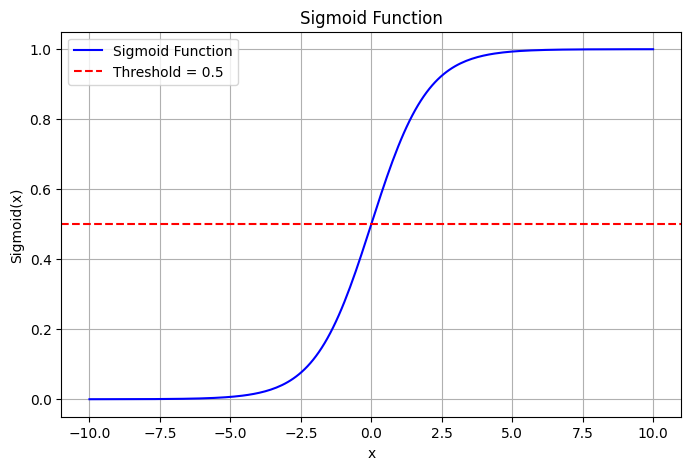

In [34]:
#session 10 3
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
x = np.linspace(-10, 10, 200)
y = sigmoid(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, color='blue', label='Sigmoid Function')
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.title("Sigmoid Function")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
#session 10 4
def classify(probability, threshold=0.5):
    if probability >= threshold:
        return "Viral"
    else:
        return "Not Viral"

probabilities = [0.2, 0.6, 0.8]

for p in probabilities:
    print(f"{p} --> {classify(p, 0.5)}")

for p in probabilities:
    print(f"{p} --> {classify(p, 0.7)}")

0.2 --> Not Viral
0.6 --> Viral
0.8 --> Viral
0.2 --> Not Viral
0.6 --> Not Viral
0.8 --> Viral


In [36]:
# session 11 1
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier

data = pd.read_csv("/content/flipkart.csv")

x = data["Review"]
y = data["Label"]

vectorizer = CountVectorizer()
x_vector = vectorizer.fit_transform(x)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_vector, y)

test = vectorizer.transform(["excellent camera"])

prediction = model.predict(test)

print(prediction[0])

positive
